Model Accuracy: 1.0

Enter new student details
Attendance (%): 90
Internal Marks (out of 50): 47
Study Hours per day: 2
12th Marks (%): 88

Predicted Student Status: Best Student


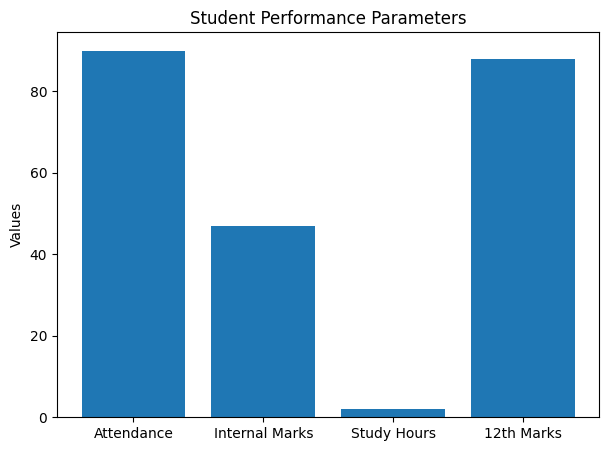

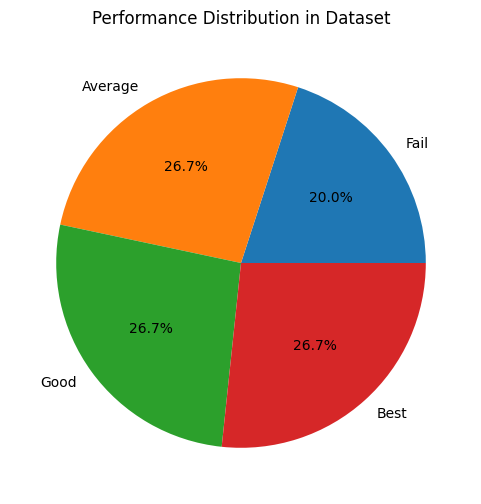

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# -------------------------------
# Step 1: Dataset
# -------------------------------
data = {
    "attendance": [90,85,70,60,95,50,80,65,88,72,92,55,78,68,82],
    "internal_marks": [45,40,30,20,48,18,35,25,42,28,46,19,34,24,38],
    "study_hours": [3,2,2,1,4,1,3,2,3,2,4,1,2,2,3],
    "twelfth_marks": [85,80,70,60,90,55,78,65,88,72,92,58,75,66,79],
    "performance": [3,2,1,0,3,0,2,1,3,1,3,0,2,1,2]  # 0=Fail,1=Average,2=Good,3=Best
}

df = pd.DataFrame(data)

# -------------------------------
# Step 2: Split dataset
# -------------------------------
X = df[["attendance", "internal_marks", "study_hours", "twelfth_marks"]]
y = df["performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 3: Train Decision Tree
# -------------------------------
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# -------------------------------
# Step 4: Test accuracy
# -------------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# -------------------------------
# Step 5: New Student Input
# -------------------------------
print("\nEnter new student details")

attendance = int(input("Attendance (%): "))
internal_marks = int(input("Internal Marks (out of 50): "))
study_hours = int(input("Study Hours per day: "))
twelfth_marks = int(input("12th Marks (%): "))

# Correct DataFrame input (no warning)
new_student = pd.DataFrame({
    "attendance": [attendance],
    "internal_marks": [internal_marks],
    "study_hours": [study_hours],
    "twelfth_marks": [twelfth_marks]
})

prediction = model.predict(new_student)[0]

# -------------------------------
# Step 6: Classify student
# -------------------------------
if prediction == 0:
    status = "Fail / Weak Student"
elif prediction == 1:
    status = "Average Student"
elif prediction == 2:
    status = "Good Student"
else:
    status = "Best Student"

print("\nPredicted Student Status:", status)

# -------------------------------
# Step 7: Bar Graph
# -------------------------------
parameters = ["Attendance", "Internal Marks", "Study Hours", "12th Marks"]
values = [attendance, internal_marks, study_hours, twelfth_marks]

plt.figure(figsize=(7,5))
plt.bar(parameters, values)
plt.title("Student Performance Parameters")
plt.ylabel("Values")
plt.show()

# -------------------------------
# Step 8: Pie Chart
# -------------------------------
performance_counts = df["performance"].value_counts().sort_index()
labels = ["Fail", "Average", "Good", "Best"]

plt.figure(figsize=(6,6))
plt.pie(performance_counts, labels=labels, autopct="%1.1f%%")
plt.title("Performance Distribution in Dataset")
plt.show()